#  Pure Prompt-on-Demand Road Damage & Infrastructure Segmentation
### Murni SAM 3.1 / SAM 3 (Promptable Concept Segmentation) — Tanpa YOLO, Tanpa Koordinat Manual

Notebook ini melakukan segmentasi permukaan jalan & infrastruktur (**Pothole, Manhole, Traffic Sign, Road Crack**, atau kelas apa pun) secara **100% Pure SAM Prompt-on-Demand**, murni menggunakan kemampuan SAM tanpa detektor eksternal (YOLO/YOLO-World).

---

###  Apa yang Baru di Versi Ini?

1. **Benar-benar *Loosely Coupled* per Gambar**
   Deteksi tidak lagi bergantung pada koordinat `box`/`point` yang di-hardcode untuk satu gambar tertentu. Semua kelas didefinisikan sebagai **prompt teks** di satu dictionary (`CLASS_PROMPTS`). Ingin mengubah objek yang dideteksi? Cukup ubah teks prompt-nya — **tidak perlu mengubah kode inti sama sekali**, dan otomatis berlaku ke gambar/video apa pun.

2. **Default Model: SAM 3.1 → SAM 3 → SAM 2.1 (fallback otomatis)**
   Notebook mencoba memuat `sam3_1.pt` (SAM 3.1 — Object Multiplex, paling baru) terlebih dahulu, lalu `sam3.pt` (SAM 3), dan baru turun ke `sam2.1_t.pt` (SAM 2.1 Tiny, auto-download) jika keduanya tidak tersedia secara lokal.

3. **Presence-Aware Detection — Tidak Dipaksakan**
   Jika sebuah kelas memang tidak ada pada gambar/frame, sistem **tidak akan menampilkan atau menghitungnya**. Tidak ada mask atau box yang dipaksakan hanya karena prompt diberikan — sesuai dengan *presence head* SAM 3 yang membedakan "apakah konsep ada" dari "di mana lokasinya".

4. **Video Sepenuhnya Bisa Dikonfigurasi**
   Satu dictionary `VIDEO_CONFIG` mengatur: model apa yang dipakai, kelas apa saja yang dideteksi, ambang confidence, jumlah frame, resolusi proses — semuanya independen dari pipeline gambar.

5. **Satu Fungsi Inti untuk Semuanya**
   `run_prompt_detection()` dipakai baik untuk gambar tunggal maupun setiap frame video — sehingga perilaku selalu konsisten (*single source of truth*, tidak ada duplikasi logika).

---


## 1. Setup Environment & Instalasi

SAM 3 / SAM 3.1 (mode prompt teks) baru tersedia di Ultralytics **>= 8.3.237** lewat kelas `SAM3SemanticPredictor`. Sel di bawah memastikan versi yang terpasang cukup baru, lalu memuat seluruh dependensi.


In [1]:
# Jalankan sekali jika versi Ultralytics Anda masih lama (opsional, aman diulang)
# !pip install -U ultralytics


In [2]:
import os
import time
from pathlib import Path

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import SAM

# SAM3SemanticPredictor & SAM3VideoSemanticPredictor baru ada di Ultralytics >= 8.3.237.
# Jika belum tersedia, notebook akan otomatis turun ke mode visual (box/point) SAM 2.1.
try:
    from ultralytics.models.sam import SAM3SemanticPredictor
    _SAM3_TEXT_PROMPT_READY = True
except ImportError:
    _SAM3_TEXT_PROMPT_READY = False

print(f"Ultralytics version   : {ultralytics.__version__}")
print(f"PyTorch version       : {torch.__version__}")
print(f"CUDA Available        : {torch.cuda.is_available()}")
print(f"SAM3SemanticPredictor : {'Tersedia ' if _SAM3_TEXT_PROMPT_READY else 'TIDAK tersedia  (upgrade: pip install -U ultralytics)'}")

if torch.cuda.is_available():
    DEVICE = 0
    print(f"GPU Device Name       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM Total            : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    DEVICE = "cpu"
    print("⚠️ CUDA tidak terdeteksi, inferensi akan berjalan di CPU (lambat untuk SAM 3/3.1).")


Ultralytics version   : 8.4.126
PyTorch version       : 2.13.0+cu130
CUDA Available        : True
SAM3SemanticPredictor : Tersedia 
GPU Device Name       : NVIDIA GeForce RTX 3080 Ti
VRAM Total            : 11.63 GB


## 2. Pemuatan Model SAM (Adaptif: SAM 3.1 → SAM 3 → SAM 2.1)

Urutan prioritas checkpoint bisa diubah bebas lewat `SAM_CHECKPOINT_PRIORITY`. Karena bobot `sam3_1.pt`/`sam3.pt` bersifat *gated* (harus diunduh manual dan disetujui lewat halaman model di Hugging Face — `facebook/sam3` / `facebook/sam3.1`), notebook ini akan:

- Memakainya **jika file tersebut sudah ada** di direktori kerja, dan mengaktifkan **mode `concept`** (deteksi berbasis prompt teks — ini mode default/yang direkomendasikan).
- Jika tidak ditemukan, otomatis turun ke `sam2.1_t.pt` (auto-download oleh Ultralytics) dengan **mode `visual`** (box/point manual, mode lama/legacy) — lihat catatan di bagian akhir notebook.

> 💡 Ingin memaksa pakai model tertentu? Cukup ubah urutan/isi `SAM_CHECKPOINT_PRIORITY` di sel berikut.


In [3]:
# Urutan prioritas checkpoint. Default: SAM 3.1 (Object Multiplex, tercepat untuk multi-objek)
# -> SAM 3 -> SAM 2.1 Tiny (fallback ringan, hemat VRAM, cocok untuk GPU kecil seperti RTX 3050).
SAM_CHECKPOINT_PRIORITY = ["sam3_1.pt", "sam3.pt", "sam2.1_t.pt"]


def resolve_sam_checkpoint(priority_list=SAM_CHECKPOINT_PRIORITY):
    """Pilih checkpoint pertama yang tersedia sesuai prioritas.

    Checkpoint keluarga SAM 3 (`sam3_1.pt`, `sam3.pt`) bersifat gated sehingga harus
    sudah ada secara lokal. Checkpoint SAM 2.1 selalu dianggap tersedia karena
    di-auto-download oleh Ultralytics saat pertama kali dipakai.
    """
    for ckpt in priority_list:
        if ckpt.startswith("sam2"):
            return ckpt
        if Path(ckpt).exists():
            return ckpt
    return priority_list[-1]


def get_sam_mode(checkpoint_name):
    """`concept` = deteksi berbasis prompt teks (SAM 3 / SAM 3.1); `visual` = box/point manual (SAM 2.1)."""
    return "concept" if checkpoint_name.startswith("sam3") else "visual"


SAM_CHECKPOINT = resolve_sam_checkpoint()
SAM_MODE = get_sam_mode(SAM_CHECKPOINT)

if SAM_MODE == "concept" and not _SAM3_TEXT_PROMPT_READY:
    print("⚠️ File SAM 3/3.1 ditemukan, tetapi `SAM3SemanticPredictor` tidak tersedia di versi Ultralytics ini.")
    print("   Jalankan `pip install -U ultralytics` lalu restart kernel. Sementara itu, turun ke mode visual SAM 2.1.")
    SAM_CHECKPOINT, SAM_MODE = "sam2.1_t.pt", "visual"

print(f"Checkpoint terpilih : {SAM_CHECKPOINT}")
print(f"Mode deteksi        : {'🅰 Prompt Teks / Concept (PCS) — direkomendasikan' if SAM_MODE == 'concept' else '🅱️ Visual Box/Point — legacy, perlu koordinat manual per gambar'}")

if SAM_MODE == "visual":
    print("\nCatatan: untuk mengaktifkan mode prompt teks, unduh `sam3_1.pt` atau `sam3.pt`")
    print("dari halaman model resmi di Hugging Face (facebook/sam3.1 atau facebook/sam3),")
    print("lalu taruh filenya di direktori kerja notebook ini dan jalankan ulang sel ini.")


Checkpoint terpilih : sam3_1.pt
Mode deteksi        : 🅰 Prompt Teks / Concept (PCS) — direkomendasikan


In [4]:
sam_predictor = None       # Instance SAM3SemanticPredictor (mode "concept")
sam_model_visual = None    # Instance SAM biasa (mode "visual")
SAM_ACTIVE_IMGSZ = None    # Construction-time image size for the active backend


def build_sam_backend(checkpoint, mode, conf=0.25, imgsz=1024, device=DEVICE):
    """Membangun backend SAM sesuai mode, dan menyimpannya ke variabel global.

    Dipanggil ulang otomatis apabila pipeline video meminta checkpoint atau
    construction-time imgsz yang berbeda dari backend concept yang sedang aktif.
    """
    global sam_predictor, sam_model_visual, SAM_ACTIVE_IMGSZ

    if mode == "concept":
        overrides = dict(
            conf=conf,
            task="segment",
            mode="predict",
            model=checkpoint,
            device=device,
            imgsz=imgsz,
            half=torch.cuda.is_available(),
            verbose=False,
            save=False,
        )
        sam_predictor = SAM3SemanticPredictor(overrides=overrides)
        sam_model_visual = None
        SAM_ACTIVE_IMGSZ = int(imgsz)
        return sam_predictor
    else:
        sam_model_visual = SAM(checkpoint)
        sam_predictor = None
        SAM_ACTIVE_IMGSZ = int(imgsz)
        return sam_model_visual


print(f"Memuat Pure SAM ({SAM_CHECKPOINT}, mode={SAM_MODE})...")
build_sam_backend(SAM_CHECKPOINT, SAM_MODE)
print(" Backend SAM siap dipakai untuk Prompt-on-Demand!")


Memuat Pure SAM (sam3_1.pt, mode=concept)...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
 Backend SAM siap dipakai untuk Prompt-on-Demand!


## 3. Konfigurasi Kelas via Prompt Teks — Inti dari *Loose Coupling*

`CLASS_PROMPTS` adalah **satu-satunya tempat** yang perlu diubah untuk mengganti objek yang dideteksi. Setiap entri berisi:

- `text` — frasa benda (noun phrase) yang dicari SAM 3/3.1, mis. `"pothole on the road"`.
- `color` — warna overlay (BGR) untuk kelas tersebut.
- `label` — teks label yang ditampilkan di gambar/video.

Tidak ada koordinat, tidak ada nama file gambar tertentu di sini — dictionary ini berlaku untuk **gambar maupun video mana pun**, karena SAM 3/3.1 mencari konsepnya sendiri di seluruh frame.

> 💡 Menambah kelas baru = menambah satu entri di dictionary ini. Menghapus kelas = menghapus satu entri. Tidak ada bagian kode lain yang perlu disentuh.


In [5]:
CLASS_PROMPTS = {
    "pothole": {
        "text": "pothole on the road, damaged asphalt hole.",
        "label": "Pothole (Lubang Jalan)",
        "color": (0, 0, 255),        # Merah (BGR)
    },
    # "manhole": {
    #     "text": "manhole cover, sewer cover on the road, either circle or square or rectangular, usually metal or concrete.",
    #     "label": "Manhole (Tutup Got)",
    #     "color": (0, 255, 0),        # Hijau (BGR)
    # },
    "road_crack": {
        "text": "Crack lines on road",
        "label": "Road Crack (Retakan Aspal)",
        "color": (255, 0, 0),        # Biru (BGR)
    },
    # "traffic_sign": {
    #     "text": "traffic sign",
    #     "label": "Traffic Sign (Rambu Jalan)",
    #     "color": (0, 255, 255),      # Kuning (BGR)
    # },

    # "water puddle": {
    #     "text": "water inside pothole or puddle, occasionally brown colour",
    #     "label": "Water Puddle",
    #     "color": (255, 0, 255),   # Magenta
    # },
    # "fallen_leaves": {
    #     "text": "leaves on the ground",
    #     "label": "Fallen Leaves",
    #     "color": (255, 255, 0),   # Cyan
    # },
}

CONFIDENCE_THRESHOLD = 0.2  # Ambang confidence global untuk mode "concept"

print(" CLASS_PROMPTS aktif:")
for name, cfg in CLASS_PROMPTS.items():
    print(f"  • '{name}' → prompt: \"{cfg['text']}\"  |  label: {cfg['label']}")


 CLASS_PROMPTS aktif:
  • 'pothole' → prompt: "pothole on the road, damaged asphalt hole."  |  label: Pothole (Lubang Jalan)
  • 'road_crack' → prompt: "Crack lines on road"  |  label: Road Crack (Retakan Aspal)


## 4. Fungsi Inti Deteksi & Visualisasi (Core Engine)

Semua pipeline di bawah (gambar tunggal, pengujian per kelas, unified multi-prompt, dan video) memanggil **satu fungsi yang sama**: `run_prompt_detection()`. Fungsi ini otomatis memilih backend (`concept` atau `visual`) sesuai `SAM_MODE`, dan **hanya mengembalikan kelas yang benar-benar terdeteksi** — kelas yang tidak ditemukan pada gambar akan dilewati begitu saja, tidak dipaksakan.


In [ ]:
def _extract_instances(result):
    """Return masks, confidence, and SAM text class IDs from one Results object."""
    if result is None:
        return None, None, None
    masks_obj = getattr(result, "masks", None)
    if masks_obj is None or getattr(masks_obj, "data", None) is None or len(masks_obj.data) == 0:
        return None, None, None

    masks = masks_obj.data.cpu().numpy()
    boxes_obj = getattr(result, "boxes", None)
    if boxes_obj is not None and getattr(boxes_obj, "conf", None) is not None:
        confs = boxes_obj.conf.cpu().numpy()
    else:
        confs = np.ones(len(masks), dtype=np.float32)
    if boxes_obj is not None and getattr(boxes_obj, "cls", None) is not None:
        class_ids = boxes_obj.cls.cpu().numpy().astype(np.int64)
    else:
        class_ids = None
    return masks, confs, class_ids


_SAM_TMP_FRAME_PATH = Path(".sam3_tmp_frame.jpg")
    

def _sam_set_image(predictor, image):
    """`set_image` pada beberapa versi Ultralytics hanya menerima path file.
    Fungsi ini mencoba ndarray langsung dulu, lalu jatuh ke file sementara bila gagal.
    """
    try:
        predictor.set_image(image)
    except Exception:
        cv2.imwrite(str(_SAM_TMP_FRAME_PATH), image)
        predictor.set_image(str(_SAM_TMP_FRAME_PATH))


def detect_concept_by_text(image_bgr, class_prompts, conf_threshold=CONFIDENCE_THRESHOLD):
    """SAM 3/3.1 concept segmentation with ONE GPU call for ALL text prompts.

    The CLASS_PROMPTS interface stays unchanged. A separate-prompt fallback is
    retained for Ultralytics builds whose batched result shape/class-id behavior
    is incompatible with the expected boxes.cls mapping.
    """
    if not class_prompts:
        return {}

    _sam_set_image(sam_predictor, image_bgr)
    class_names = list(class_prompts.keys())
    texts = [class_prompts[name]["text"] for name in class_names]

    def build_detections_from_result(result, names):
        masks, confs, class_ids = _extract_instances(result)
        # Ultralytics returns masks=None and zero boxes when no concept is present.
        # This is a valid empty result, not a reason to run every prompt again.
        if masks is None:
            boxes = getattr(result, "boxes", None)
            if boxes is not None and len(boxes) == 0:
                return {}, np.empty(0, dtype=np.int64)
            return None, class_ids
        if class_ids is None:
            return None, class_ids

        if class_ids.size and int(class_ids.max()) >= len(names):
            print("⚠️ Batched SAM returned an out-of-range boxes.cls index; falling back to separate prompts.")
            return None, class_ids
        if class_ids.size and int(class_ids.min()) < 0:
            print("⚠️ Batched SAM returned a negative boxes.cls index; falling back to separate prompts.")
            return None, class_ids

        detections_out = {}
        for class_idx, cls_name in enumerate(names):
            keep = (class_ids == class_idx) & (confs >= conf_threshold)
            if not keep.any():
                continue
            cfg = class_prompts[cls_name]
            detections_out[cls_name] = {
                "masks": masks[keep],
                "confidences": confs[keep],
                "label": cfg.get("label", cls_name),
                "color": cfg.get("color", (0, 0, 255)),
            }
        return detections_out, class_ids

    try:
        raw = sam_predictor(text=texts)
    except Exception as e:
        print(f"⚠️ Multi-prompt SAM inference gagal, fallback ke prompt terpisah: {e}")
        raw = None

    if raw is not None:
        results = raw if isinstance(raw, (list, tuple)) else [raw]
        result = results[0] if results else None
        detections, class_ids = (
            build_detections_from_result(result, class_names)
            if result is not None else (None, None)
        )
        if detections is not None:
            return detections

        # Compatibility fallback: one Results object per prompt.
        if len(results) == len(class_names):
            print("ℹ️ Using per-prompt Results compatibility fallback.")
            detections_fallback = {}
            for idx, cls_name in enumerate(class_names):
                m, c, _ = _extract_instances(results[idx])
                if m is None:
                    continue
                keep = c >= conf_threshold
                if not keep.any():
                    continue
                cfg = class_prompts[cls_name]
                detections_fallback[cls_name] = {
                    "masks": m[keep],
                    "confidences": c[keep],
                    "label": cfg.get("label", cls_name),
                    "color": cfg.get("color", (0, 0, 255)),
                }
            return detections_fallback

    # Last-resort fallback: preserve the known-working independent-prompt path.
    detections = {}
    for cls_name in class_names:
        cfg = class_prompts[cls_name]
        try:
            raw_one = sam_predictor(text=[cfg["text"]])
        except Exception as e:
            print(f"⚠️ Prompt '{cfg['text']}' (kelas '{cls_name}') gagal dijalankan: {e}")
            continue

        result_one = raw_one[0] if isinstance(raw_one, (list, tuple)) else raw_one
        masks, confs, _ = _extract_instances(result_one)
        if masks is None:
            continue

        keep = confs >= conf_threshold
        if not keep.any():
            continue

        detections[cls_name] = {
            "masks": masks[keep],
            "confidences": confs[keep],
            "label": cfg.get("label", cls_name),
            "color": cfg.get("color", (0, 0, 255)),
        }
    return detections


def detect_visual_by_geometry(image_bgr, class_prompts, device=DEVICE):
    """Mode fallback (legacy): box/point manual SAM 2.1. Tiap kelas butuh key
    tambahan `boxes`/`points` yang sesuai gambar yang sedang diproses (lihat
    bagian catatan legacy di akhir notebook untuk contoh lengkap).
    """
    detections = {}
    for cls_name, cfg in class_prompts.items():
        boxes = cfg.get("boxes")
        points = cfg.get("points")
        if not boxes and not points:
            continue

        res = sam_model_visual.predict(
            source=image_bgr,
            bboxes=boxes,
            points=points,
            labels=cfg.get("point_labels", [1] * len(points) if points else None),
            retina_masks=True,
            verbose=False,
            device=device,
        )[0]

        masks, confs = _extract_instances(res)
        if masks is None:
            continue

        detections[cls_name] = {
            "masks": masks,
            "confidences": confs,
            "label": cfg.get("label", cls_name),
            "color": cfg.get("color", (0, 0, 255)),
        }
    return detections


def run_prompt_detection(image_bgr, class_prompts, conf_threshold=CONFIDENCE_THRESHOLD, device=DEVICE):
    """Satu pintu masuk deteksi untuk seluruh notebook (gambar & video).

    Pemanggil tidak perlu tahu backend mana yang sedang aktif — cukup berikan
    gambar (ndarray BGR) dan dictionary kelas, fungsi ini yang menyesuaikan.
    """
    if SAM_MODE == "concept":
        return detect_concept_by_text(image_bgr, class_prompts, conf_threshold)
    return detect_visual_by_geometry(image_bgr, class_prompts, device)


print(" Fungsi 'run_prompt_detection' siap — inti loosely-coupled pipeline.")


In [7]:
def render_detections(image_bgr, detections):
    """Render masks/contours/labels with all per-instance image work ROI-confined.

    The blend remains sequential and additive (`overlay * 1.0 + color * 0.45`),
    preserving the original overlap semantics. Labels are drawn on the full
    overlay at the same point in the per-instance order, so later masks/contours
    retain the original ability to overwrite earlier label pixels.
    """
    h, w = image_bgr.shape[:2]
    overlay = image_bgr.copy()
    records = []

    for cls_name, det in detections.items():
        color = det["color"]
        label = det["label"]

        for i, mask in enumerate(det["masks"]):
            mask_bin = (mask > 0.5).astype(np.uint8)
            if mask_bin.shape != (h, w):
                mask_bin = cv2.resize(
                    mask_bin, (w, h), interpolation=cv2.INTER_NEAREST
                )

            conf_val = float(det["confidences"][i]) if i < len(det["confidences"]) else None

            x, y, bw, bh = cv2.boundingRect(mask_bin)
            pixel_area = int(cv2.countNonZero(mask_bin))

            if bw > 0 and bh > 0 and pixel_area > 0:
                # A thickness-2 contour can touch one pixel outside the mask
                # bounding box. Pad the ROI while keeping the mask itself unchanged.
                pad = 2
                x0 = max(0, x - pad)
                y0 = max(0, y - pad)
                x1 = min(w, x + bw + pad)
                y1 = min(h, y + bh + pad)

                sub_mask = mask_bin[y0:y1, x0:x1]
                sub_img = overlay[y0:y1, x0:x1]

                layer = np.empty_like(sub_img)
                layer[:] = color
                blended = cv2.addWeighted(sub_img, 1.0, layer, 0.45, 0)
                cv2.copyTo(blended, sub_mask, sub_img)

                contours, _ = cv2.findContours(
                    sub_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )
                cv2.drawContours(sub_img, contours, -1, color, 2)

                conf_txt = f" {conf_val * 100:.0f}%" if conf_val is not None else ""
                # Keep labels on the full overlay, preserving the original
                # per-instance draw order and avoiding ROI clipping.
                cv2.putText(
                    overlay,
                    f"{label}{conf_txt}",
                    (x, max(20, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    (255, 255, 255),
                    2,
                )

            records.append({
                "class": cls_name,
                "label": label,
                "instance": i + 1,
                "pixel_area": pixel_area,
                "area_percent": (pixel_area / (h * w)) * 100.0,
                "confidence": conf_val,
            })

    return overlay, records


def show_coordinate_helper(image_path, title="Panduan Koordinat Gambar"):
    """Utilitas opsional: menampilkan gambar dengan grid piksel. Hanya diperlukan
    untuk mode legacy (visual box/point); pada mode 'concept' tidak dibutuhkan lagi
    karena tidak ada koordinat yang harus ditentukan manual.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f" Gambar tidak ditemukan: {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f"{title} (Lebar: {w}px, Tinggi: {h}px)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.4, color="yellow")
    plt.xlabel("Koordinat X (piksel)")
    plt.ylabel("Koordinat Y (piksel)")
    plt.show()


print(" Fungsi 'render_detections' dan 'show_coordinate_helper' siap digunakan!")


 Fungsi 'render_detections' dan 'show_coordinate_helper' siap digunakan!


## 5. Pengujian pada Gambar — Otomatis, Tanpa Koordinat per Gambar

Loop di bawah berjalan untuk **semua gambar** di `TEST_IMAGES` dan **semua kelas** di `CLASS_PROMPTS` sekaligus — karena prompt-nya berbasis teks, tidak ada penyesuaian koordinat yang dibutuhkan per gambar baru. Kelas yang tidak ditemukan pada suatu gambar akan dilaporkan sebagai "tidak ditemukan", bukan dipaksakan muncul.


In [8]:
TEST_IMAGES = ["testimage3.png", "testimage4.png", "testimage6.png","testimage5.png"]
TEST_IMAGES = [p for p in TEST_IMAGES if Path(p).exists()]

if not TEST_IMAGES:
    print(" Tidak ada file pada TEST_IMAGES yang ditemukan di direktori kerja.")
    print("   Tambahkan nama file gambar Anda ke list TEST_IMAGES di atas.")

for img_path in TEST_IMAGES:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f" Gagal membaca: {img_path}")
        continue

    detections = run_prompt_detection(img_bgr, CLASS_PROMPTS)
    overlay, records = render_detections(img_bgr, detections)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Gambar Asli: {img_path}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Hasil Pure SAM ({len(records)} objek terdeteksi)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    found_classes = sorted(set(r["class"] for r in records))
    missing_classes = [c for c in CLASS_PROMPTS if c not in found_classes]

    print(f" Kelas terdeteksi pada '{img_path}': {found_classes or '(tidak ada)'}")
    if missing_classes:
        print(f"➖ Tidak ditemukan (dilewati, bukan dipaksakan): {missing_classes}")
    for r in records:
        conf_txt = f", confidence={r['confidence']:.2f}" if r["confidence"] is not None else ""
        print(f"    • {r['label']} #{r['instance']}: {r['pixel_area']:,} px "
              f"({r['area_percent']:.2f}% dari gambar){conf_txt}")
    print("-" * 60)


Ultralytics 8.4.126 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11905MiB)


/home/bondry/miky/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


ValueError: not enough values to unpack (expected 3, got 2)

## 6. Menguji atau Mengganti Target Deteksi Secara Fleksibel

Karena semuanya berbasis prompt teks, kita bisa menguji satu kelas saja, gabungan sebagian kelas, atau bahkan kelas yang **sama sekali baru** — cukup dengan membuat dictionary prompt baru, tanpa menyentuh kode inti sama sekali.


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


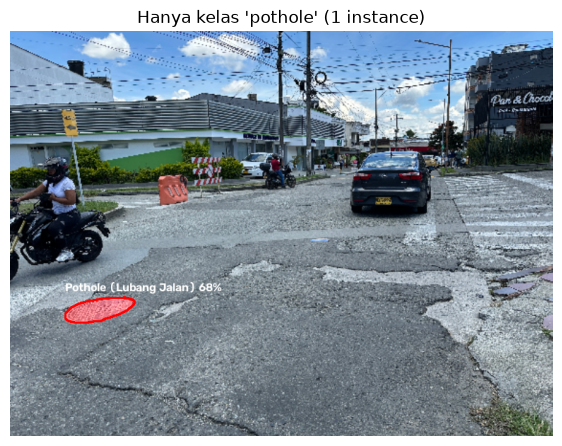

In [ ]:
# Contoh A: menguji hanya SATU kelas ("pothole") pada gambar pertama yang tersedia
if TEST_IMAGES:
    sample_img = cv2.imread(TEST_IMAGES[0])
    only_pothole = {"pothole": CLASS_PROMPTS["pothole"]}

    dets = run_prompt_detection(sample_img, only_pothole)
    overlay, records = render_detections(sample_img, dets)

    plt.figure(figsize=(7, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Hanya kelas 'pothole' ({len(records)} instance)")
    plt.axis("off")
    plt.show()


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


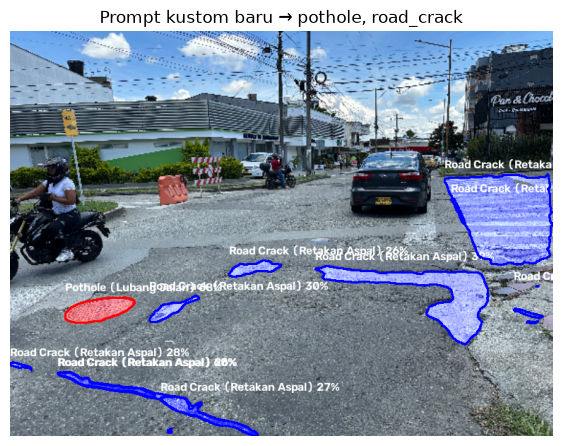

In [ ]:
# Contoh B: mengganti target deteksi TOTAL BARU hanya dengan mengedit teks prompt —
# tidak ada perubahan kode, tidak ada koordinat baru yang perlu dicari.
custom_prompts = {
 
    "vegetation": {
        "text": "grass or plants growing through road cracks",
        "label": "Vegetasi Liar",
        "color": (0, 200, 0),
    },
      "pothole": {
            "text": "pothole on the road, damaged asphalt hole",
            "label": "Pothole (Lubang Jalan)",
            "color": (0, 0, 255),        # Merah (BGR)
        },
        "manhole": {
            "text": "manhole cover, sewer cover on the road",
            "label": "Manhole (Tutup Got)",
            "color": (0, 255, 0),        # Hijau (BGR)
        },
        "road_crack": {
            "text": "crack on asphalt road surface",
            "label": "Road Crack (Retakan Aspal)",
            "color": (255, 0, 0),        # Biru (BGR)
        },
        "traffic_sign": {
            "text": "traffic sign ",
            "label": "Traffic Sign (Rambu Jalan)",
            "color": (0, 255, 255),      # Kuning (BGR)
        },
    
        "water puddle": {
            "text": "water inside pothole or puddle",
            "label": "pothole",
            "color": (255, 0, 255),   # Magenta
        },
        "dry_leaves": {
            "text": "fallen leaves, usually coloured green or yellow if dry, at the ground",
            "label": "Daun Kering",
            "color": (255, 255, 0),   # Cyan
        },
}

if TEST_IMAGES:
    sample_img = cv2.imread(TEST_IMAGES[0])
    dets_custom = run_prompt_detection(sample_img, custom_prompts)
    overlay, records = render_detections(sample_img, dets_custom)

    plt.figure(figsize=(7, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    title_found = ", ".join(sorted(set(r["class"] for r in records))) or "tidak ada kelas ditemukan"
    plt.title(f"Prompt kustom baru → {title_found}")
    plt.axis("off")
    plt.show()


## 7. Unified Multi-Prompt Pipeline (Seluruh Kelas Sekaligus)

Sel ini menjalankan **seluruh `CLASS_PROMPTS`** pada satu gambar contoh, menggabungkan seluruh mask ke satu overlay, dan menyusun tabel metrik ringkas — hanya untuk kelas yang benar-benar terdeteksi.


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


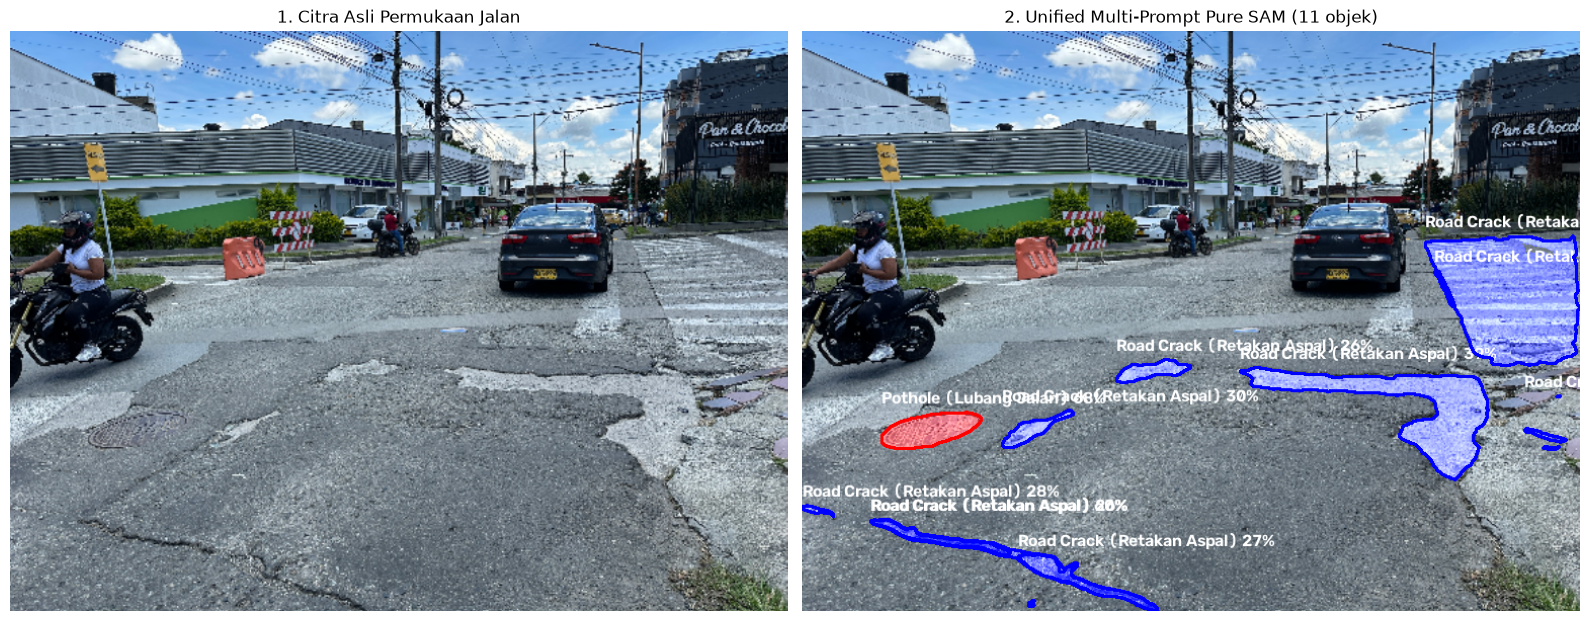

📊 Ringkasan Metrik per Kelas:
  ✅ Pothole (Lubang Jalan): 1 instance, total 0.56% dari luas gambar
  ✅ Road Crack (Retakan Aspal): 10 instance, total 7.17% dari luas gambar


In [ ]:
IMAGE_SAMPLE = TEST_IMAGES[0] if TEST_IMAGES else None

if IMAGE_SAMPLE:
    img_base = cv2.imread(IMAGE_SAMPLE)
    detections = run_prompt_detection(img_base, CLASS_PROMPTS)
    combined_overlay, unified_records = render_detections(img_base, detections)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Citra Asli Permukaan Jalan", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(combined_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"2. Unified Multi-Prompt Pure SAM ({len(unified_records)} objek)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("📊 Ringkasan Metrik per Kelas:")
    for cls_name in CLASS_PROMPTS:
        cls_records = [r for r in unified_records if r["class"] == cls_name]
        if not cls_records:
            print(f"  ➖ {CLASS_PROMPTS[cls_name]['label']}: tidak ditemukan pada gambar ini")
            continue
        total_area_pct = sum(r["area_percent"] for r in cls_records)
        print(f"  ✅ {CLASS_PROMPTS[cls_name]['label']}: {len(cls_records)} instance, "
              f"total {total_area_pct:.2f}% dari luas gambar")
else:
    print("⚠️ Tidak ada gambar contoh di TEST_IMAGES untuk dijalankan.")


## 8. Bagian Video — Model, Kelas, dan Threshold Sepenuhnya Bisa Diatur

`VIDEO_CONFIG` adalah satu tempat untuk mengatur seluruh perilaku pipeline video:

| Key | Fungsi |
|---|---|
| `model_checkpoint` | Model SAM yang dipakai khusus untuk video. `None` = pakai model gambar yang sudah dimuat. Bisa diisi model lain (mis. `"sam2.1_t.pt"`) agar video diproses lebih cepat/hemat VRAM. |
| `classes` | Dictionary kelas (format sama seperti `CLASS_PROMPTS`) — bisa subset, superset, atau sepenuhnya berbeda dari yang dipakai di pipeline gambar. |
| `conf_threshold` | Ambang confidence khusus video. |
| `max_frames` | `None` = proses seluruh video; isi angka untuk uji cepat. |
| `skip_frames` | 1 = tiap frame diproses, 2 = tiap 2 frame (lebih cepat). |
| `resize_dim` | Resolusi pemrosesan (mengatur trade-off kecepatan vs kualitas). |

Kelas yang tidak muncul pada suatu frame otomatis dilewati di frame tersebut (bukan dipaksakan) — HUD hanya menampilkan hitungan `0`/`-` untuk kelas yang memang absen di frame itu.


In [ ]:
VIDEO_CONFIG = {
    "input_path": "testvideo5.mp4",
    "output_path": "hasil_video5_pure_sam_optimized.mp4",
    "model_checkpoint": None,     # None = pakai backend yang sama dengan pipeline gambar
    "classes": CLASS_PROMPTS,     # Interface CLASS_PROMPTS tetap sama
    "conf_threshold": 0.25,

    # Video performance controls
    "max_frames": 300,             # None = seluruh video
    "skip_frames": 2,              # 1 = output setiap frame; >1 = sengaja membuang frame
    "resize_dim": (640, 480),
    "sam_imgsz": 560,  # construction-time SAM input size

    # Keyframe detection:
    # Full SAM text-prompt inference hanya dijalankan setiap N frame.
    # Frame di antaranya memakai temporal mask propagation.
    "detect_interval": 5,

    # Optical-flow propagation between SAM keyframes.
    # 0.5 = hitung flow pada separuh resolusi untuk mengurangi CPU cost.
    "propagation": "flow",  # use "phase" for cheaper global motion
    "flow_scale": 0.5,

    # Jika True, lakukan redetection lebih cepat ketika propagated masks
    # hilang seluruhnya. Ini menjaga recovery tanpa kembali ke full inference.
    "redetect_on_empty": False,  # wait for the next scheduled keyframe
}

print("VIDEO_CONFIG aktif:")
print(f"  • Model          : {VIDEO_CONFIG['model_checkpoint'] or f'(ikut pipeline gambar: {SAM_CHECKPOINT})'}")
print(f"  • Kelas          : {list(VIDEO_CONFIG['classes'].keys())}")
print(f"  • Threshold      : {VIDEO_CONFIG['conf_threshold']}")
print(f"  • Max frames     : {VIDEO_CONFIG['max_frames'] or 'seluruh video'}")
print(f"  • Frame step     : {VIDEO_CONFIG['skip_frames']}")
print(f"  • Resize         : {VIDEO_CONFIG['resize_dim']}")
print(f"  • Detect interval: setiap {VIDEO_CONFIG['detect_interval']} frame")
print(f"  • Flow scale     : {VIDEO_CONFIG['flow_scale']}")


In [ ]:
# Benchmark the construction-time SAM image size before processing the video.
# This measures a short slice of VIDEO_CONFIG["input_path"] and reports both timing
# and detected-instance totals per class. Use the counts, not timing alone, when
# choosing the size.
# Ultralytics may round the requested imgsz to the model stride (for example,
# 768 may become 770), so treat the printed setting as the requested size.
BENCH_SAM_IMGSZ = (448, 560, 770)
BENCH_KEYFRAMES = min(12, int(VIDEO_CONFIG.get("max_frames") or 12))
BENCH_REPEATS = 2

bench_checkpoint = VIDEO_CONFIG.get("model_checkpoint") or SAM_CHECKPOINT
if get_sam_mode(bench_checkpoint) != "concept":
    print("SAM imgsz sweep skipped: text-prompt benchmarking requires SAM 3/3.1 concept mode.")
else:
    bench_conf = float(VIDEO_CONFIG.get("conf_threshold", CONFIDENCE_THRESHOLD))
    bench_classes = VIDEO_CONFIG["classes"]
    bench_names = list(bench_classes.keys())
    bench_texts = [bench_classes[name]["text"] for name in bench_names]

    cap_bench = cv2.VideoCapture(str(VIDEO_CONFIG["input_path"]))
    bench_frames = []
    if cap_bench.isOpened():
        while len(bench_frames) < BENCH_KEYFRAMES:
            ok, frame = cap_bench.read()
            if not ok:
                break
            if VIDEO_CONFIG.get("resize_dim"):
                frame = cv2.resize(
                    frame, VIDEO_CONFIG["resize_dim"], interpolation=cv2.INTER_AREA
                )
            bench_frames.append(frame)
    cap_bench.release()

    if not bench_frames:
        print(
            "Benchmark skipped: video not found or no frames readable: "
            f"{VIDEO_CONFIG['input_path']}"
        )
    else:
        print("=" * 72)
        print(
            f"SAM IMGSZ SWEEP — {len(bench_frames)} keyframe(s) from "
            f"{VIDEO_CONFIG['input_path']}"
        )
        print(f"Classes: {bench_names}")
        for requested_imgsz in BENCH_SAM_IMGSZ:
            predictor_bench = SAM3SemanticPredictor(overrides=dict(
                conf=bench_conf,
                task="segment",
                mode="predict",
                model=bench_checkpoint,
                device=DEVICE,
                imgsz=requested_imgsz,
                half=torch.cuda.is_available(),
                verbose=False,
                save=False,
            ))

            # One warm-up pass at this size. The timed section below measures
            # set_image + batched text inference per keyframe.
            predictor_bench.set_image(bench_frames[0])
            predictor_bench(text=bench_texts)
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            counts = {name: 0 for name in bench_names}
            class_ids_ok = True
            t0 = time.perf_counter()

            for _ in range(BENCH_REPEATS):
                for frame_bench in bench_frames:
                    predictor_bench.set_image(frame_bench)
                    raw_bench = predictor_bench(text=bench_texts)
                    result_bench = (
                        raw_bench[0]
                        if isinstance(raw_bench, (list, tuple))
                        else raw_bench
                    )
                    _, _, ids_bench = _extract_instances(result_bench)

                    if ids_bench is None or (
                        ids_bench.size and (
                            int(ids_bench.min()) < 0
                            or int(ids_bench.max()) >= len(bench_names)
                        )
                    ):
                        class_ids_ok = False
                    elif ids_bench.size:
                        for idx_bench in ids_bench:
                            counts[bench_names[int(idx_bench)]] += 1

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            elapsed_ms = (time.perf_counter() - t0) * 1000.0
            per_keyframe_ms = elapsed_ms / (len(bench_frames) * BENCH_REPEATS)

            count_text = ", ".join(
                f"{name}={counts[name] / BENCH_REPEATS:.1f}"
                for name in bench_names
            )
            suffix = (
                ""
                if class_ids_ok
                else " | WARNING: boxes.cls unavailable/invalid; "
                     "counts are not trustworthy"
            )
            print(
                f"  imgsz={requested_imgsz:>3d}: "
                f"{per_keyframe_ms:7.1f} ms/keyframe | "
                f"avg instances/keyframe: {count_text}{suffix}"
            )

            del predictor_bench
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        print("=" * 72)


## 9. Video Processing Engine — Keyframe + Temporal Propagation

Versi video ini mempertahankan **interface `CLASS_PROMPTS` yang sama**, tetapi tidak lagi menjalankan SAM text-prompt pada setiap frame.

Strateginya:
1. Jalankan SAM penuh pada keyframe.
2. Pindahkan mask ke frame berikutnya dengan optical flow.
3. Jalankan SAM lagi secara berkala untuk memperbaiki drift dan menemukan objek baru.

Dengan `detect_interval=5`, hanya sekitar 1 dari 5 frame yang memanggil SAM; frame lainnya memakai propagation CPU yang jauh lebih ringan. `skip_frames` tetap tersedia sebagai opsi untuk sengaja mengurangi jumlah frame output.

Parameter utama:
- `detect_interval=3` → lebih akurat/stabil, lebih banyak SAM
- `detect_interval=5` → rekomendasi awal untuk RTX 3080 Ti
- `detect_interval=8` atau `10` → lebih cepat, tetapi tracking bisa lebih mudah drift
- `flow_scale=0.5` → rekomendasi awal; turunkan ke `0.35` jika CPU menjadi bottleneck


In [ ]:
def ensure_backend_for_video(video_config):
    """Memuat/reuse backend SAM sesuai VIDEO_CONFIG."""
    global SAM_CHECKPOINT, SAM_MODE

    target_ckpt = video_config.get("model_checkpoint") or SAM_CHECKPOINT
    target_imgsz = int(video_config.get("sam_imgsz", 560))
    target_mode = get_sam_mode(target_ckpt)

    backend_missing = (
        (target_mode == "concept" and sam_predictor is None)
        or (target_mode == "visual" and sam_model_visual is None)
    )
    needs_rebuild = (
        target_ckpt != SAM_CHECKPOINT
        or backend_missing
        or (target_mode == "concept" and SAM_ACTIVE_IMGSZ != target_imgsz)
    )

    if needs_rebuild:
        print(
            f"Memuat backend SAM untuk video: {target_ckpt} "
            f"(mode={target_mode}, imgsz={target_imgsz})"
        )
        build_sam_backend(
            target_ckpt,
            target_mode,
            conf=video_config.get("conf_threshold", CONFIDENCE_THRESHOLD),
            imgsz=target_imgsz,
        )
        SAM_CHECKPOINT, SAM_MODE = target_ckpt, target_mode

    return target_mode


def _copy_detections(detections):
    """Copy detections so propagated masks never mutate the keyframe result."""
    copied = {}
    for cls_name, det in detections.items():
        copied[cls_name] = {
            "masks": np.array(det["masks"], copy=True),
            "confidences": np.array(det["confidences"], copy=True),
            "label": det["label"],
            "color": det["color"],
        }
    return copied


def _translate_detections_phase(prev_frame, curr_frame, detections):
    """Translate prior masks using global phase correlation (cheap CPU propagation)."""
    if not detections:
        return {}

    h, w = curr_frame.shape[:2]
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    shift, response = cv2.phaseCorrelate(
        np.float32(prev_gray), np.float32(curr_gray)
    )
    dx, dy = shift
    if (
        not np.isfinite(dx) or not np.isfinite(dy)
        or not np.isfinite(response)
        or abs(dx) >= w or abs(dy) >= h
    ):
        return detections

    matrix = np.array(
        [[1.0, 0.0, float(round(dx))],
         [0.0, 1.0, float(round(dy))]],
        dtype=np.float32,
    )

    translated = {}
    for cls_name, det in detections.items():
        masks_out = []
        for mask in det.get("masks", []):
            mask_bin = (mask > 0.5).astype(np.float32)
            if mask_bin.shape != (h, w):
                mask_bin = cv2.resize(
                    mask_bin, (w, h), interpolation=cv2.INTER_NEAREST
                )
            warped = cv2.warpAffine(
                mask_bin, matrix, (w, h),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0,
            )
            masks_out.append(warped)

        if masks_out:
            translated[cls_name] = {
                "masks": np.stack(masks_out, axis=0),
                "confidences": np.asarray(
                    det.get("confidences", []), dtype=np.float32
                ).copy(),
                "label": det["label"],
                "color": det["color"],
            }

    return translated


def _propagate_detections(prev_frame, curr_frame, detections, flow_scale=0.5):
    """Propagate SAM masks from the previous processed frame using dense optical flow.

    SAM is still responsible for semantic discovery. Optical flow only moves the
    already-detected masks between nearby frames, which is much cheaper than
    running the text-prompt model on every frame.
    """
    if not detections:
        return {}

    h, w = curr_frame.shape[:2]
    scale = float(np.clip(flow_scale, 0.25, 1.0))
    fw = max(32, int(w * scale))
    fh = max(32, int(h * scale))

    prev_gray = cv2.cvtColor(
        cv2.resize(prev_frame, (fw, fh), interpolation=cv2.INTER_AREA),
        cv2.COLOR_BGR2GRAY,
    )
    curr_gray = cv2.cvtColor(
        cv2.resize(curr_frame, (fw, fh), interpolation=cv2.INTER_AREA),
        cv2.COLOR_BGR2GRAY,
    )

    flow_small = cv2.calcOpticalFlowFarneback(
        prev_gray,
        curr_gray,
        None,
        pyr_scale=0.5,
        levels=2,
        winsize=15,
        iterations=2,
        poly_n=5,
        poly_sigma=1.2,
        flags=0,
    )

    # Convert flow back to full-resolution pixel units.
    flow_x = cv2.resize(flow_small[..., 0], (w, h), interpolation=cv2.INTER_LINEAR)
    flow_y = cv2.resize(flow_small[..., 1], (w, h), interpolation=cv2.INTER_LINEAR)
    flow_x *= (w / fw)
    flow_y *= (h / fh)

    grid_x, grid_y = np.meshgrid(
        np.arange(w, dtype=np.float32),
        np.arange(h, dtype=np.float32),
    )

    # Backward remap: for each current pixel, sample its corresponding
    # previous-frame pixel.
    map_x = grid_x - flow_x
    map_y = grid_y - flow_y

    propagated = {}
    for cls_name, det in detections.items():
        masks_out = []
        confs_out = []

        for i, mask in enumerate(det["masks"]):
            mask_bin = (mask > 0.5).astype(np.uint8) * 255
            if mask_bin.shape != (h, w):
                mask_bin = cv2.resize(
                    mask_bin, (w, h), interpolation=cv2.INTER_NEAREST
                )

            warped = cv2.remap(
                mask_bin,
                map_x,
                map_y,
                interpolation=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0,
            )

            # Remove tiny flow artifacts.
            warped = (warped > 127).astype(np.float32)
            if warped.sum() < 16:
                continue

            masks_out.append(warped)
            if i < len(det["confidences"]):
                confs_out.append(float(det["confidences"][i]))

        if masks_out:
            propagated[cls_name] = {
                "masks": np.stack(masks_out, axis=0),
                "confidences": np.asarray(confs_out, dtype=np.float32),
                "label": det["label"],
                "color": det["color"],
            }

    return propagated


def _count_detection_pixels(records, class_prompts):
    """Consume metrics already computed by render_detections; do not touch masks again."""
    counts = {cls: 0 for cls in class_prompts}
    total_damage_px = 0
    for record in records:
        cls_name = record["class"]
        counts[cls_name] = counts.get(cls_name, 0) + 1
        total_damage_px += int(record["pixel_area"])
    return counts, total_damage_px


def process_video_pure_sam(video_config):
    """3080 Ti optimized video pipeline.

    The text-prompt interface is unchanged:
        VIDEO_CONFIG["classes"] = CLASS_PROMPTS

    Instead of running SAM on every frame:
      1. Run full text-prompt SAM on a keyframe.
      2. Propagate those masks with optical flow for the next frames.
      3. Re-run SAM periodically to correct drift and discover new objects.

    This trades a small amount of temporal accuracy for a large reduction in
    expensive SAM calls.
    """
    mode = ensure_backend_for_video(video_config)

    video_path = video_config["input_path"]
    output_path = video_config["output_path"]
    class_prompts = video_config["classes"]
    conf_th = video_config.get("conf_threshold", CONFIDENCE_THRESHOLD)

    max_frames = video_config.get("max_frames")
    skip_frames = max(1, int(video_config.get("skip_frames", 1)))
    resize_dim = video_config.get("resize_dim")

    detect_interval = max(1, int(video_config.get("detect_interval", 5)))
    flow_scale = float(video_config.get("flow_scale", 0.5))
    propagation = str(video_config.get("propagation", "flow")).lower()
    redetect_on_empty = bool(video_config.get("redetect_on_empty", False))

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Video tidak ditemukan: {video_path}")

    orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out_w, out_h = resize_dim if resize_dim else (orig_w, orig_h)

    # We process/output every selected frame. Propagation therefore preserves
    # the original video timing when skip_frames == 1.
    output_fps = fps_in / skip_frames
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        output_fps,
        (out_w, out_h),
    )

    if not writer.isOpened():
        cap.release()
        raise IOError(f"Gagal membuka VideoWriter: {output_path}")

    print("=" * 68)
    print("3080 Ti OPTIMIZED SAM VIDEO PIPELINE")
    print(f"Video           : {video_path}")
    print(f"Model           : {SAM_CHECKPOINT} (mode={mode})")
    print(f"Kelas           : {list(class_prompts.keys())}")
    print(f"Resolusi        : {orig_w}x{orig_h} -> {out_w}x{out_h}")
    print(f"Input FPS       : {fps_in:.1f}")
    print(f"Output FPS      : {output_fps:.1f}")
    print(f"Detect interval : every {detect_interval} processed frame(s)")
    print(f"Flow scale      : {flow_scale:.2f}")
    print(f"Frame limit     : {max_frames if max_frames else f'all ({total_frames})'}")
    print("=" * 68)

    frame_idx = 0
    processed = 0
    sam_calls = 0
    propagated_frames = 0
    start_time = time.perf_counter()

    temporal_log = []
    sample_frames = []

    previous_frame = None
    previous_detections = {}
    last_detection_frame = -1

    gallery_target = max_frames or total_frames or 1
    gallery_stride = max(1, gallery_target // 5)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Preserve the existing skip_frames option.
        if frame_idx % skip_frames != 0:
            frame_idx += 1
            continue

        if max_frames and processed >= max_frames:
            break

        frame_proc = (
            cv2.resize(frame, resize_dim, interpolation=cv2.INTER_AREA)
            if resize_dim
            else frame
        )

        # Full SAM inference only on keyframes.
        need_detection = (
            processed == 0
            or previous_frame is None
            or (processed - last_detection_frame) >= detect_interval
        )

        # If propagation produced nothing, recover immediately with SAM.
        if (
            not need_detection
            and redetect_on_empty
            and not previous_detections
        ):
            need_detection = True

        t0 = time.perf_counter()

        if need_detection:
            detections = run_prompt_detection(
                frame_proc,
                class_prompts,
                conf_threshold=conf_th,
            )
            sam_calls += 1
            last_detection_frame = processed
            source = "SAM"
        else:
            if propagation == "phase" and previous_frame is not None:
                detections = _translate_detections_phase(
                    previous_frame, frame_proc, previous_detections
                )
                propagated_frames += 1
                source = "PHASE"
            else:
                detections = _propagate_detections(
                    previous_frame,
                    frame_proc,
                    previous_detections,
                    flow_scale=flow_scale,
                )
                propagated_frames += 1
                source = "FLOW"

        inference_time = time.perf_counter() - t0

        annotated, records = render_detections(frame_proc, detections)
        frame_time = time.perf_counter() - t0

        counts, total_damage_px = _count_detection_pixels(
            records,
            class_prompts,
        )

        # Rolling end-to-end throughput, not just one-frame inference time.
        elapsed = max(time.perf_counter() - start_time, 1e-6)
        throughput = (processed + 1) / elapsed

        # --- HUD ---
        n_lines = len(class_prompts)
        hud_bg = annotated.copy()
        cv2.rectangle(
            hud_bg,
            (10, 10),
            (470, 100 + n_lines * 22),
            (20, 20, 20),
            -1,
        )
        annotated = cv2.addWeighted(
            annotated, 0.25, hud_bg, 0.75, 0
        )

        cv2.putText(
            annotated,
            f"SAM Video | Frame {frame_idx}/{total_frames}",
            (20, 32),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
        )
        cv2.putText(
            annotated,
            f"{throughput:.1f} FPS | {source} | frame {frame_time*1000:.0f} ms",
            (20, 54),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.48,
            (0, 255, 200),
            1,
        )
        cv2.putText(
            annotated,
            f"SAM calls: {sam_calls} | keyframe every {detect_interval}",
            (20, 76),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.46,
            (255, 220, 120),
            1,
        )

        y = 100
        for cls_name, cfg in class_prompts.items():
            color = cfg.get("color", (255, 255, 255))
            label = cfg.get("label", cls_name)
            cnt = counts.get(cls_name, 0)

            cv2.circle(annotated, (28, y - 4), 6, color, -1)
            status = str(cnt) if cnt > 0 else "-"
            cv2.putText(
                annotated,
                f"{label}: {status}",
                (42, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.48,
                (255, 255, 255),
                1,
            )
            y += 22

        writer.write(annotated)

        temporal_log.append({
            "frame": frame_idx,
            "time_sec": frame_idx / fps_in,
            "source": source,
            "counts": counts,
            "damage_pixels": total_damage_px,
            "damage_pct": (
                total_damage_px / (out_w * out_h)
            ) * 100.0,
        })

        if processed % gallery_stride == 0:
            sample_frames.append((frame_idx, annotated.copy()))

        previous_frame = frame_proc.copy()
        previous_detections = _copy_detections(detections)

        processed += 1
        frame_idx += 1

        if processed % 15 == 0:
            elapsed = max(time.perf_counter() - start_time, 1e-6)
            print(
                f"  {processed}/{max_frames or total_frames} frames | "
                f"{processed / elapsed:.1f} FPS | "
                f"SAM calls={sam_calls} | "
                f"flow frames={propagated_frames}"
            )

    cap.release()
    writer.release()

    total_time = max(time.perf_counter() - start_time, 1e-6)
    avg_fps = processed / total_time if processed else 0.0
    sam_fraction = sam_calls / processed if processed else 0.0

    print("=" * 68)
    print("VIDEO PROCESSING COMPLETE")
    print(f"Frames processed   : {processed}")
    print(f"Total time         : {total_time:.2f} s")
    print(f"Average throughput : {avg_fps:.2f} FPS")
    print(f"SAM inference calls: {sam_calls}")
    print(f"Flow-propagated    : {propagated_frames}")
    print(f"SAM frame fraction : {sam_fraction:.1%}")
    print(f"Output             : {output_path}")
    print("=" * 68)

    return temporal_log, sample_frames


print("3080 Ti optimized video engine ready.")


In [ ]:
# Guard against the video size optimization silently becoming a no-op.
ensure_backend_for_video(VIDEO_CONFIG)
if SAM_MODE == "concept":
    assert SAM_ACTIVE_IMGSZ == int(VIDEO_CONFIG["sam_imgsz"]), (
        f"SAM_ACTIVE_IMGSZ={SAM_ACTIVE_IMGSZ}, "
        f"VIDEO_CONFIG['sam_imgsz']={VIDEO_CONFIG['sam_imgsz']}"
    )
    print(f"Verified: concept backend is built at imgsz={SAM_ACTIVE_IMGSZ}.")
else:
    print("Visual SAM backend active; construction-time imgsz is not used by this path.")


### 9.1 Rekomendasi tuning RTX 3080 Ti

Mulai dari:

```python
VIDEO_CONFIG["detect_interval"] = 5
VIDEO_CONFIG["flow_scale"] = 0.5
VIDEO_CONFIG["resize_dim"] = (640, 480)
VIDEO_CONFIG["skip_frames"] = 1
```

Jika GPU masih sangat longgar tetapi hasil mulai drift, turunkan `detect_interval` ke `3`.

Jika CPU menjadi bottleneck, coba `flow_scale=0.35`.

Pipeline ini sengaja **tidak mengubah `CLASS_PROMPTS`**. Anda tetap dapat mengganti, menambah, atau menghapus text prompt seperti pada pipeline gambar.


## 10. Eksekusi Video Sesuai `VIDEO_CONFIG`


3080 Ti OPTIMIZED SAM VIDEO PIPELINE
Video           : testvideo5.mp4
Model           : sam3_1.pt (mode=concept)
Kelas           : ['pothole', 'road_crack']
Resolusi        : 474x854 -> 640x480
Input FPS       : 30.0
Output FPS      : 15.0
Detect interval : every 5 processed frame(s)
Flow scale      : 0.50
Frame limit     : 300
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
  15/300 frames | 10.4 FPS | SAM calls=3 | flow frames=12
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
  30/300 frames | 9.8 FPS | SAM calls=6 | flow frames=24
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING ⚠

/tmp/ipykernel_517800/3338177382.py:14: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


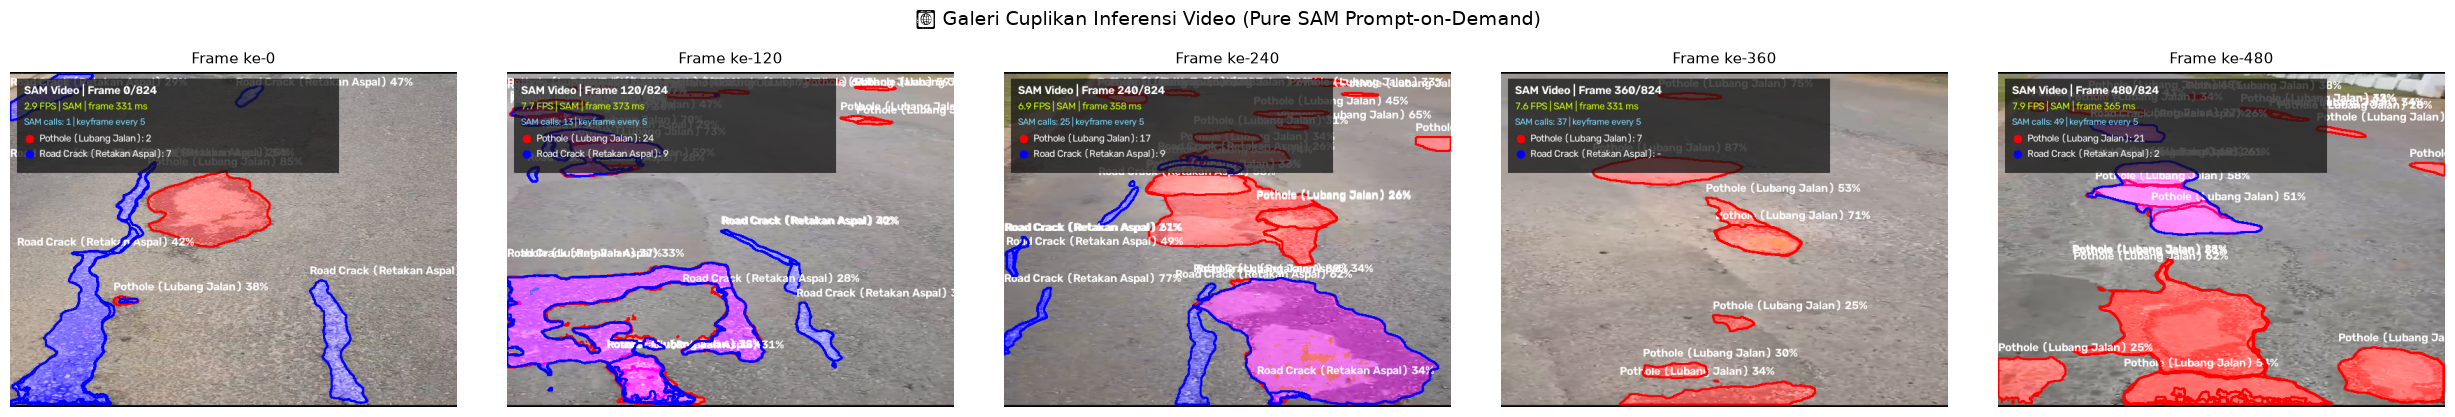

In [ ]:
if Path(VIDEO_CONFIG["input_path"]).exists():
    damage_log, sample_frames = process_video_pure_sam(VIDEO_CONFIG)

    if sample_frames:
        num_samples = len(sample_frames)
        fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 4))
        if num_samples == 1:
            axes = [axes]
        for ax, (f_idx, f_img) in zip(axes, sample_frames):
            ax.imshow(cv2.cvtColor(f_img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Frame ke-{f_idx}", fontsize=11)
            ax.axis("off")
        plt.suptitle("📸 Galeri Cuplikan Inferensi Video (Pure SAM Prompt-on-Demand)", fontsize=14, y=1.03)
        plt.tight_layout()
        plt.show()
else:
    damage_log, sample_frames = [], []
    print(f"⚠️ File video '{VIDEO_CONFIG['input_path']}' tidak ditemukan di direktori kerja.")
    print("   Letakkan file video Anda lalu jalankan ulang sel ini.")


## 11. Analisis Metrik Temporal Kerusakan Jalan

Grafik ini sepenuhnya mengikuti kelas yang didefinisikan di `VIDEO_CONFIG["classes"]` — tidak ada kelas yang di-hardcode di sini, sehingga tetap relevan berapa pun jumlah/nama kelas yang Anda pakai.


/tmp/ipykernel_517800/3760520020.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_517800/3760520020.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("grafik_analisis_temporal_jalan.png", dpi=300)


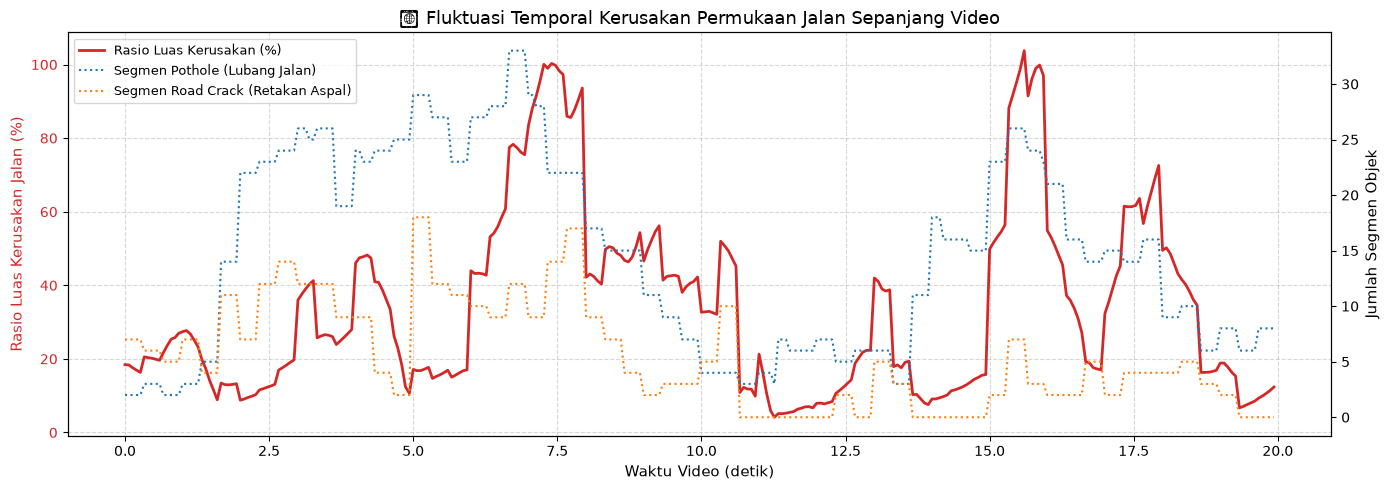

📊 KESIMPULAN ANALISIS TEMPORAL:
  • Titik kerusakan tertinggi : detik ke-15.60 (103.78% area)
  • Rata-rata rasio kerusakan : 34.05%
  • Pothole (Lubang Jalan): 4419 total kemunculan segmen, muncul di 300/300 frame
  • Road Crack (Retakan Aspal): 1655 total kemunculan segmen, muncul di 240/300 frame


In [ ]:
if damage_log:
    times = [d["time_sec"] for d in damage_log]
    dmg_pcts = [d["damage_pct"] for d in damage_log]
    class_names = list(VIDEO_CONFIG["classes"].keys())

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.set_xlabel("Waktu Video (detik)", fontsize=11)
    ax1.set_ylabel("Rasio Luas Kerusakan Jalan (%)", color="tab:red", fontsize=11)
    ax1.plot(times, dmg_pcts, color="tab:red", linewidth=2, label="Rasio Luas Kerusakan (%)")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Jumlah Segmen Objek", fontsize=11)
    palette = plt.cm.tab10.colors
    for i, cls_name in enumerate(class_names):
        counts = [d["counts"].get(cls_name, 0) for d in damage_log]
        label = VIDEO_CONFIG["classes"][cls_name].get("label", cls_name)
        ax2.plot(times, counts, linestyle=":", color=palette[i % len(palette)], label=f"Segmen {label}")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

    plt.title("📈 Fluktuasi Temporal Kerusakan Permukaan Jalan Sepanjang Video", fontsize=13)
    plt.tight_layout()
    plt.savefig("grafik_analisis_temporal_jalan.png", dpi=300)
    plt.show()

    max_idx = int(np.argmax(dmg_pcts))
    print("=" * 60)
    print("📊 KESIMPULAN ANALISIS TEMPORAL:")
    print(f"  • Titik kerusakan tertinggi : detik ke-{times[max_idx]:.2f} ({dmg_pcts[max_idx]:.2f}% area)")
    print(f"  • Rata-rata rasio kerusakan : {np.mean(dmg_pcts):.2f}%")
    for cls_name in class_names:
        label = VIDEO_CONFIG["classes"][cls_name].get("label", cls_name)
        total_cnt = sum(d["counts"].get(cls_name, 0) for d in damage_log)
        frames_present = sum(1 for d in damage_log if d["counts"].get(cls_name, 0) > 0)
        print(f"  • {label}: {total_cnt} total kemunculan segmen, muncul di {frames_present}/{len(damage_log)} frame")
    print("=" * 60)
else:
    print("Tidak ada data temporal (video belum diproses atau tidak ada frame yang terbaca).")


## 12. Catatan: Mode Legacy (Visual Box/Point) & Troubleshooting

Bagian ini hanya relevan jika notebook jatuh ke **mode `visual`** (SAM 2.1) karena `sam3_1.pt`/`sam3.pt` belum tersedia.

### Mengaktifkan mode prompt teks (direkomendasikan)
1. Minta akses & unduh bobot di halaman model resmi Hugging Face (`facebook/sam3.1` atau `facebook/sam3`).
2. Taruh file `sam3_1.pt` (atau `sam3.pt`) di direktori kerja notebook ini.
3. Pastikan `ultralytics >= 8.3.237`: `pip install -U ultralytics`.
4. Jalankan ulang notebook dari Bagian 2.

### Menggunakan mode legacy (box/point manual) jika belum punya bobot SAM 3/3.1
Format konfigurasi legacy sama seperti `CLASS_PROMPTS`, tetapi menggunakan `boxes`/`points` alih-alih `text` — dan **harus disesuaikan ulang setiap ganti gambar**, karena inilah yang coba dihindari oleh mode `concept`:

```python
LEGACY_VISUAL_PROMPTS = {
    "pothole": {
        "label": "Pothole (Lubang Jalan)",
        "color": (0, 0, 255),
        "boxes": [[424, 323, 720, 454]],   # Koordinat spesifik untuk SATU gambar tertentu
        "points": [[560, 385]],
        "point_labels": [1],
    },
}

# Gunakan show_coordinate_helper("nama_gambar.png") untuk membantu menentukan koordinat.
# detections = run_prompt_detection(img_bgr, LEGACY_VISUAL_PROMPTS)  # otomatis pakai backend visual
```

### Tips VRAM
- `sam2.1_t.pt` (Tiny) — paling ringan, cocok GPU 4 GB seperti RTX 3050.
- `sam3.pt` / `sam3_1.pt` — jauh lebih besar (≈3.3–3.5 GB model, butuh VRAM signifikan lebih banyak saat inferensi). Jika VRAM terbatas, turunkan `imgsz` pada `build_sam_backend`, kecilkan `resize_dim` pada `VIDEO_CONFIG`, atau gunakan `sam2.1_t.pt` khusus untuk video (`VIDEO_CONFIG["model_checkpoint"] = "sam2.1_t.pt"`) sambil tetap memakai SAM 3.1 untuk gambar.


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


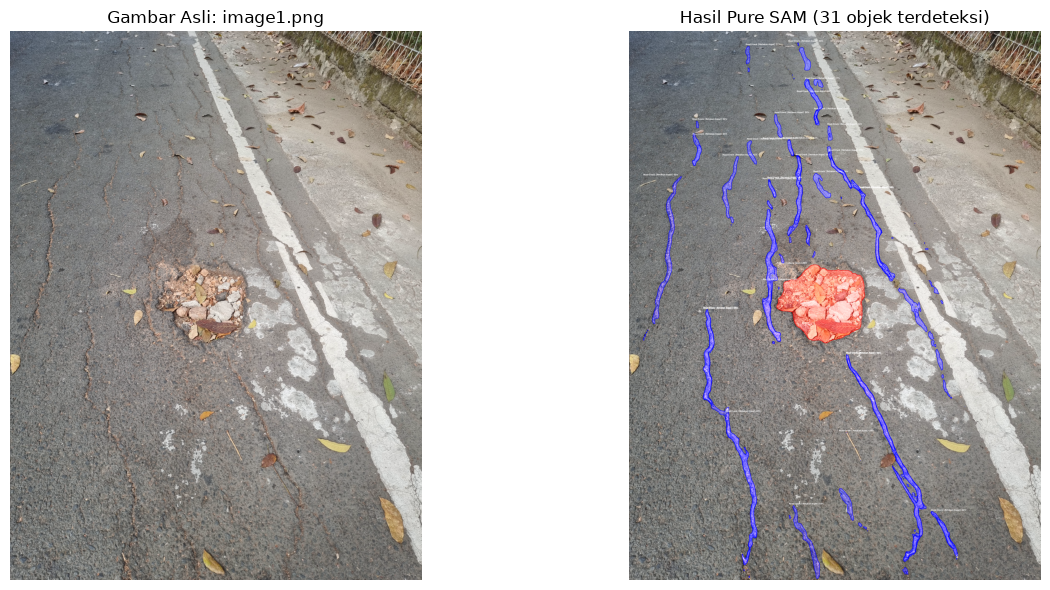

 Kelas terdeteksi pada 'image1.png': ['pothole', 'road_crack']
    • Pothole (Lubang Jalan) #1: 257,595 px (2.15% dari gambar), confidence=0.88
    • Road Crack (Retakan Aspal) #1: 31,105 px (0.26% dari gambar), confidence=0.62
    • Road Crack (Retakan Aspal) #2: 12,590 px (0.10% dari gambar), confidence=0.61
    • Road Crack (Retakan Aspal) #3: 52,031 px (0.43% dari gambar), confidence=0.56
    • Road Crack (Retakan Aspal) #4: 20,876 px (0.17% dari gambar), confidence=0.56
    • Road Crack (Retakan Aspal) #5: 64,001 px (0.53% dari gambar), confidence=0.50
    • Road Crack (Retakan Aspal) #6: 36,127 px (0.30% dari gambar), confidence=0.49
    • Road Crack (Retakan Aspal) #7: 16,917 px (0.14% dari gambar), confidence=0.43
    • Road Crack (Retakan Aspal) #8: 37,551 px (0.31% dari gambar), confidence=0.40
    • Road Crack (Retakan Aspal) #9: 5,665 px (0.05% dari gambar), confidence=0.39
    • Road Crack (Retakan Aspal) #10: 3,874 px (0.03% dari gambar), confidence=0.39
    • Road Crack 

In [ ]:
TEST_IMAGES = ["image1.png"]
TEST_IMAGES = [p for p in TEST_IMAGES if Path(p).exists()]

if not TEST_IMAGES:
    print(" Tidak ada file pada TEST_IMAGES yang ditemukan di direktori kerja.")
    print("   Tambahkan nama file gambar Anda ke list TEST_IMAGES di atas.")

for img_path in TEST_IMAGES:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f" Gagal membaca: {img_path}")
        continue

    detections = run_prompt_detection(img_bgr, CLASS_PROMPTS)
    overlay, records = render_detections(img_bgr, detections)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Gambar Asli: {img_path}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Hasil Pure SAM ({len(records)} objek terdeteksi)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    found_classes = sorted(set(r["class"] for r in records))
    missing_classes = [c for c in CLASS_PROMPTS if c not in found_classes]

    print(f" Kelas terdeteksi pada '{img_path}': {found_classes or '(tidak ada)'}")
    if missing_classes:
        print(f"➖ Tidak ditemukan (dilewati, bukan dipaksakan): {missing_classes}")
    for r in records:
        conf_txt = f", confidence={r['confidence']:.2f}" if r["confidence"] is not None else ""
        print(f"    • {r['label']} #{r['instance']}: {r['pixel_area']:,} px "
              f"({r['area_percent']:.2f}% dari gambar){conf_txt}")
    print("-" * 60)


WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


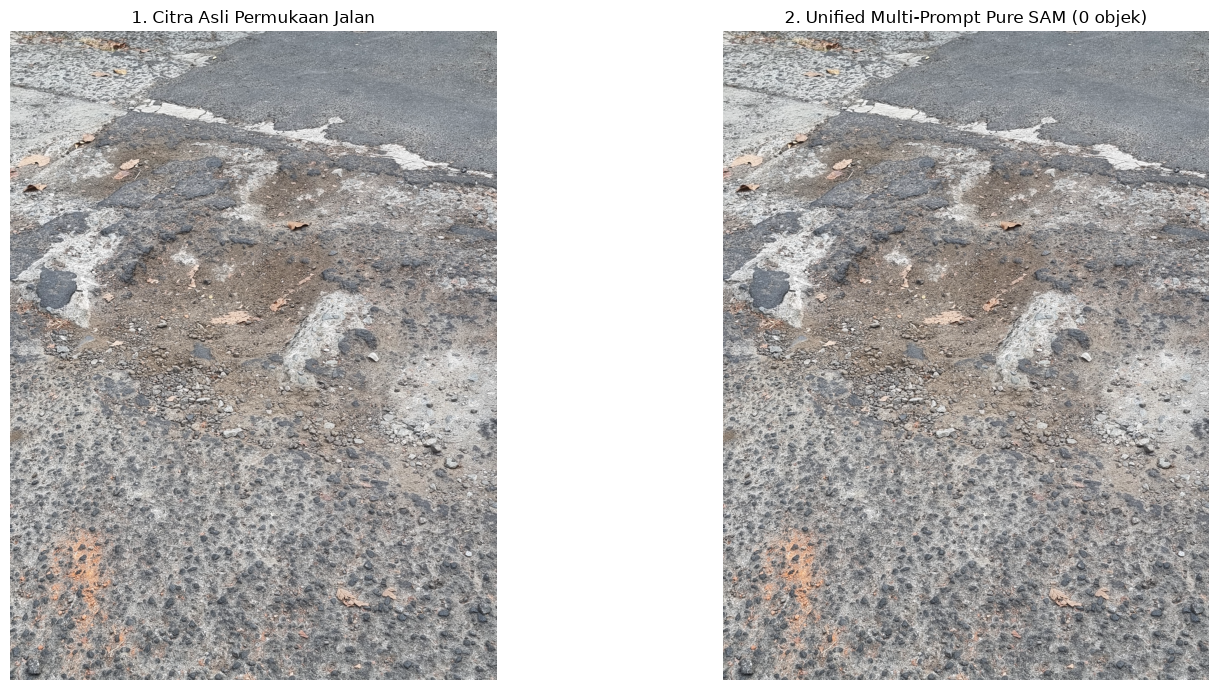

📊 Ringkasan Metrik per Kelas:
  ➖ Pothole (Lubang Jalan): tidak ditemukan pada gambar ini
  ➖ Road Crack (Retakan Aspal): tidak ditemukan pada gambar ini


In [ ]:
IMAGE_SAMPLE = "hard_image.png" if TEST_IMAGES else None

if IMAGE_SAMPLE:
    img_base = cv2.imread(IMAGE_SAMPLE)
    detections = run_prompt_detection(img_base, CLASS_PROMPTS)
    combined_overlay, unified_records = render_detections(img_base, detections)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Citra Asli Permukaan Jalan", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(combined_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"2. Unified Multi-Prompt Pure SAM ({len(unified_records)} objek)", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("📊 Ringkasan Metrik per Kelas:")
    for cls_name in CLASS_PROMPTS:
        cls_records = [r for r in unified_records if r["class"] == cls_name]
        if not cls_records:
            print(f"  ➖ {CLASS_PROMPTS[cls_name]['label']}: tidak ditemukan pada gambar ini")
            continue
        total_area_pct = sum(r["area_percent"] for r in cls_records)
        print(f"  ✅ {CLASS_PROMPTS[cls_name]['label']}: {len(cls_records)} instance, "
              f"total {total_area_pct:.2f}% dari luas gambar")
else:
    print("⚠️ Tidak ada gambar contoh di TEST_IMAGES untuk dijalankan.")
